<a href="https://colab.research.google.com/github/insafroumy/RFM-Customer-Segmentation/blob/main/RFM_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are an owner of online retail, and you need to understand the needs and preferences of your customers to deliver more personalized and effective marketing campaigns, leading to increased customer retention and revenue.

Using you retail RFM data, you need to segment the customers into groups and suggest marketing efforts for each segment to enhance customer engagement and retention:

- Cluster the data using k-means
- Use Elbow and silhouette score methods to find the optimal number of clusters
- Fit the optimal k-means model and assign cluster for every customer
- Using explanatory analysis, try to understand the characteristics of each segment, and give each segment a significant name.
- Suggest proper marketing efforts for every segment.

# RFM
## R: Recency - آخر مرة اشترى فيها العميل
## F: Frequency - كم مرة اشترى بالمجمل؟
## M: Monetary Value - كم أنفق بالمجمل؟

#Imports

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Mount Google Drive

In [3]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Get Data
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/rfm.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4338 non-null   int64  
 1   Recency        4338 non-null   int64  
 2   Frequency      4338 non-null   int64  
 3   MonetaryValue  4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


,CustomerID,Recency,Frequency,MonetaryValue
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['CustomerID'])
df.head()

,Recency,Frequency,MonetaryValue
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [9]:
# Instantiate Standard Scaler
scaler = StandardScaler()
# Fit & transform data.
scaled_df = scaler.fit_transform(df)

In [10]:
scaled_df = pd.DataFrame(scaled_df, columns=['Recency', 'Frequency', 'MonetaryValue'])

scaled_df.head()


,Recency,Frequency,MonetaryValue
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


Text(0, 0.5, 'inertia')

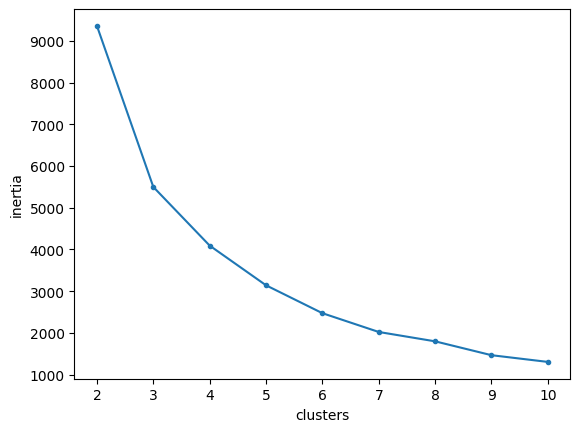

In [11]:
#Create an empty list of inertias
inertias = []
#Loop through k values between 2 and 10 and store the inertias in the list.
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, n_init = 'auto', random_state = 42)
    kmeans.fit(scaled_df)
    inertias.append(kmeans.inertia_)
#Visualize scores
plt.plot(range(2,11), inertias, marker = '.')
plt.xlabel('clusters')
plt.ylabel('inertia')

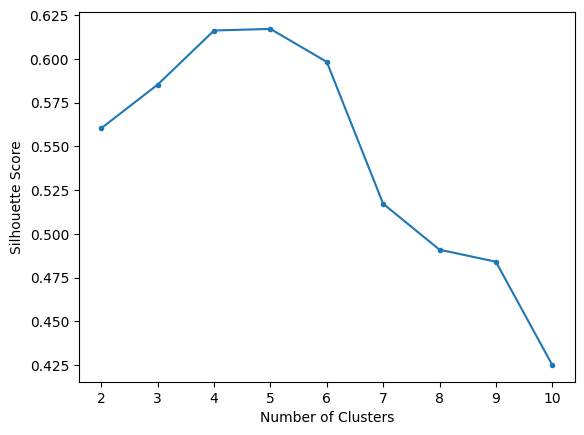

In [12]:
# Visualize different silhouette scores
# Save silhouette scores for various cluster numbers in list
silhouette_scores = []
for i in range(2, 11):
  kmeans = KMeans(n_clusters = i, n_init = 'auto', random_state = 42)
  kmeans.fit(scaled_df)
  silhouette_scores.append(silhouette_score(scaled_df, kmeans.labels_))
# Visualize scores
plt.plot(range(2, 11), silhouette_scores, marker = '.')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score');

In [13]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
kmeans_final.fit(scaled_df)

df['Cluster'] = kmeans_final.labels_
df.head()

,Recency,Frequency,MonetaryValue,Cluster
0,326,1,77183.60,3
1,2,7,4310.00,0
2,75,4,1797.24,0
3,19,1,1757.55,0
4,310,1,334.40,1


In [14]:
# Group the dataframe by cluster and aggregate by mean values
# Add as_index=False so that the clusters are a column, not the index
cluster_groups = df.groupby('Cluster', as_index=False).mean()
cluster_groups

,Cluster,Recency,Frequency,MonetaryValue
0,0,43.808170,3.686928,1358.774086
1,1,248.469426,1.553151,480.423604
2,2,1.500000,135.833333,58381.123333
3,3,15.724138,22.300493,13533.997044
4,4,7.666667,42.833333,190863.461667


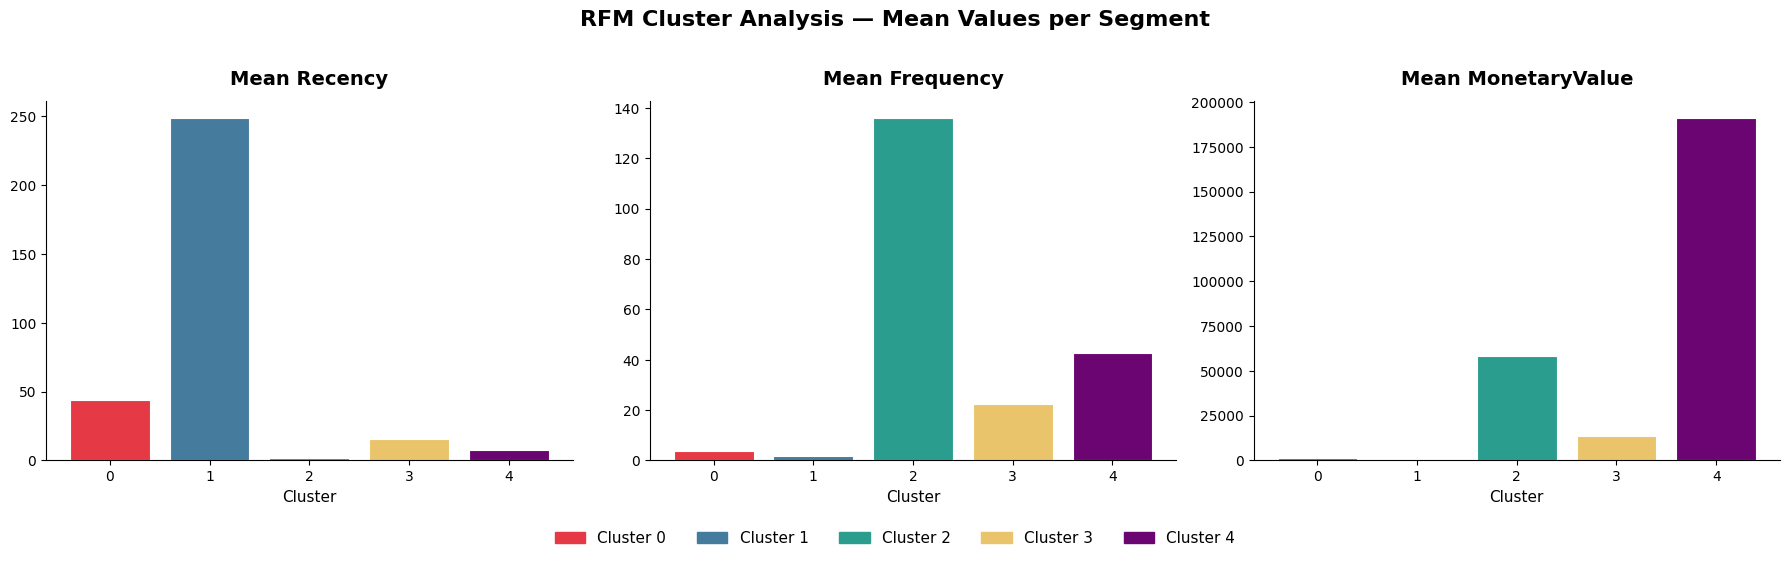

In [17]:
import matplotlib.patches as mpatches

colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#6A0572']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.ravel()

for i, col in enumerate(cluster_groups.columns[1:]):
    axes[i].bar(
        cluster_groups['Cluster'],
        cluster_groups[col],
        color=colors,
        edgecolor='white',
        linewidth=0.8
    )
    axes[i].set_title(f'Mean {col}', fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel('Cluster', fontsize=11)
    axes[i].set_xticks([0, 1, 2, 3, 4])
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=colors[j], label=cluster_labels[j]) for j in range(5)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=11, frameon=False)

plt.suptitle('RFM Cluster Analysis — Mean Values per Segment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_clusters_colored.png', dpi=150, bbox_inches='tight')
plt.show()

- Cluster 0 and 1:<br/>
Recency for both clusters, is high, espcially cluster 1, the recency considered very high, so we will focus on those clusters in the marketing campaigns.

- Cluster 2:<br/> Recency is the smallest , in the other hand the frequency is the highest, but mean monetary values are moderate, so have to give them some attention to make them spend more.
- Cluster 3: <br/>  moderate in all aspect, we have to make attention to not loose them , and turn them into a frequent customers.

- Cluster 4: <br/>  Recency is low, frequency is moderate, but mean monetary is the highest, so we need to focus on increasing the frequency.